In [1]:
%cd ..

f:\nn


# Importing Libraries

In [2]:
import pandas as pd
import numpy as np 
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from utils.augmentation_script import augment_images
from torchvision import transforms
import cv2


# Importing the DataFrame of the resized images

In [3]:
df = pd.read_csv('data/df_resized.csv')
df.head()

,path,class,resized_path
0,data\Bangunan Retak\Cracked\00001.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
1,data\Bangunan Retak\Cracked\00002.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
2,data\Bangunan Retak\Cracked\00003.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
3,data\Bangunan Retak\Cracked\00004.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
4,data\Bangunan Retak\Cracked\00005.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...


## Visualizing the barplot for both Classes before Augmentation

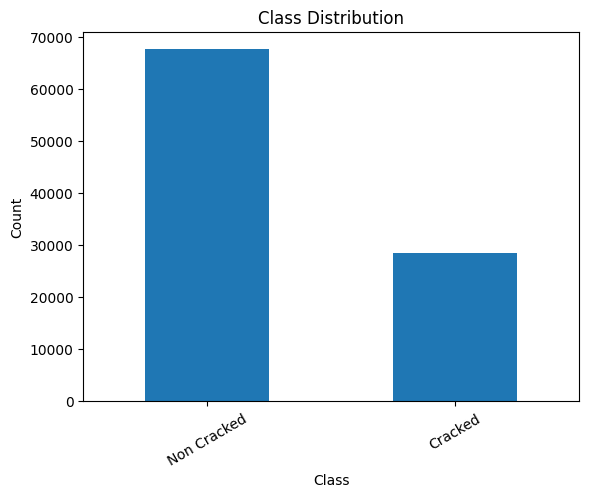

In [4]:
df['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

# Displaying images before Augmenting them

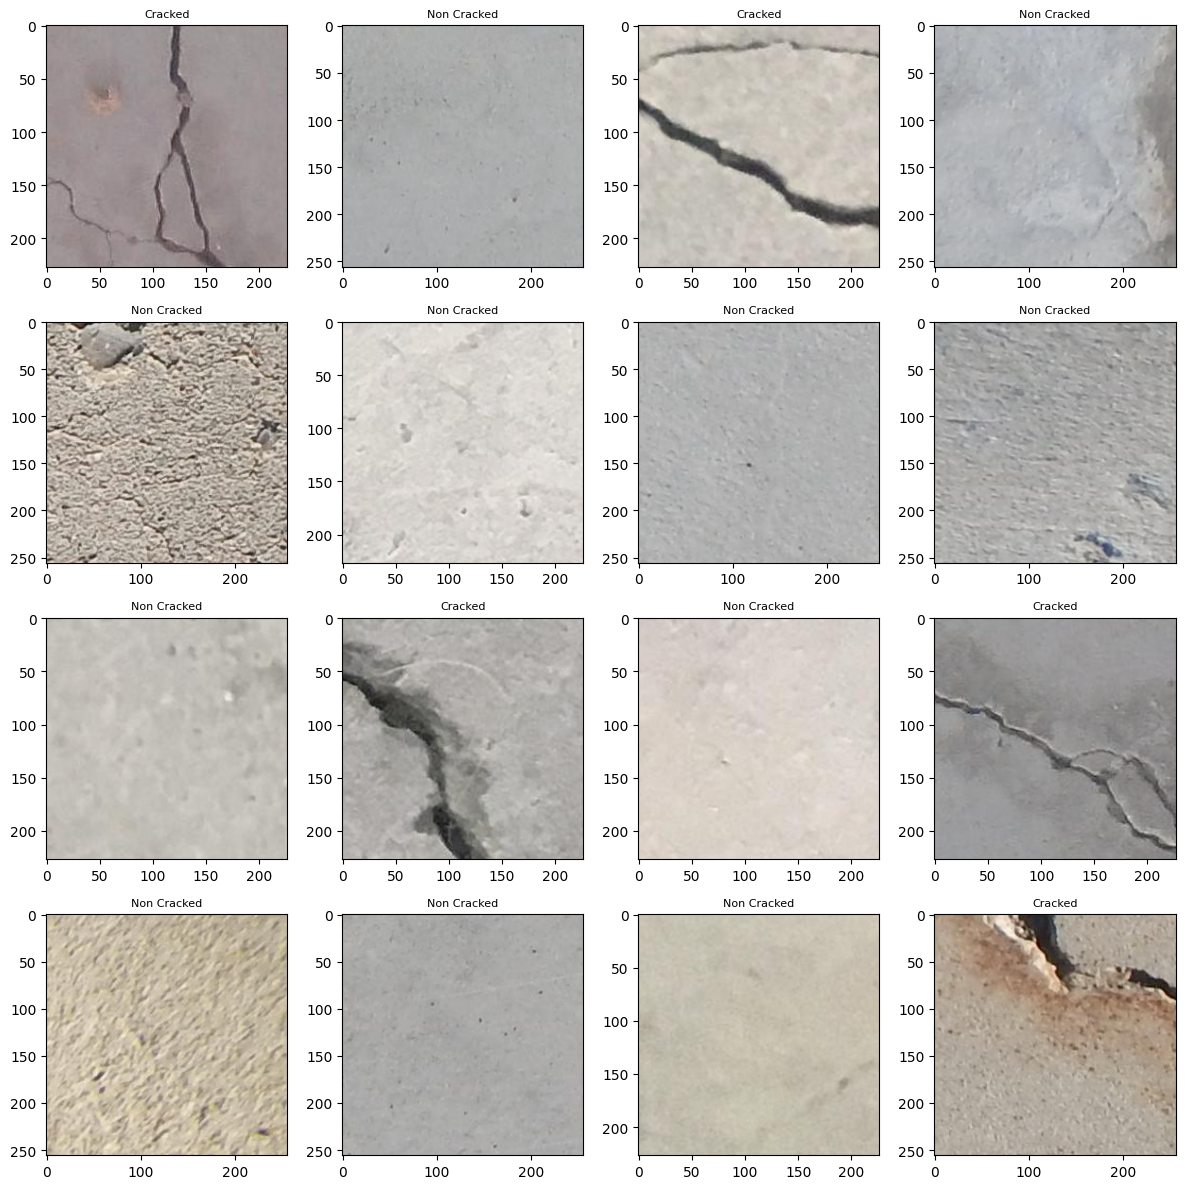

In [5]:
plt.figure(figsize=(12, 12))

sample_df = df.sample(16, random_state=11)

for i in range(16):
    img_path = sample_df.iloc[i]['path']
    label = sample_df.iloc[i]['class']

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=8)

plt.tight_layout()
plt.show()

# Augmenting the Images

Augmenting images...


100%|██████████| 96092/96092 [13:30<00:00, 118.58it/s]


<Axes: xlabel='class'>

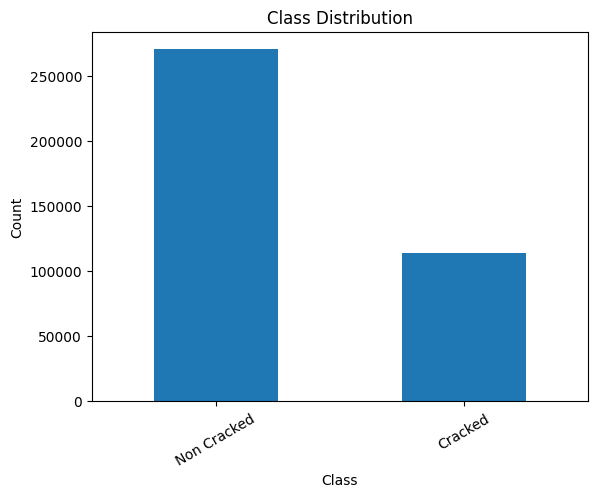

In [6]:
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

df = augment_images(df, output_path="data/augmented_images", augmentation=augmentation, num_aug_per_image=3)
display(df['class'].value_counts().plot(kind='bar'))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

In [7]:
display(df.tail(10))
df.drop(columns=['path'], inplace=True)
print("="*80)
display(df.tail(10))
df.to_csv('data/df_augmented.csv', index=False)

,path,class,resized_path
384358,NaN,Non Cracked,data\augmented_images\7140-95_resized_aug2.jpeg
384359,NaN,Non Cracked,data\augmented_images\7140-96_resized_aug0.jpeg
384360,NaN,Non Cracked,data\augmented_images\7140-96_resized_aug1.jpeg
384361,NaN,Non Cracked,data\augmented_images\7140-96_resized_aug2.jpeg
384362,NaN,Non Cracked,data\augmented_images\7140-97_resized_aug0.jpeg
384363,NaN,Non Cracked,data\augmented_images\7140-97_resized_aug1.jpeg
384364,NaN,Non Cracked,data\augmented_images\7140-97_resized_aug2.jpeg
384365,NaN,Non Cracked,data\augmented_images\7140-98_resized_aug0.jpeg
384366,NaN,Non Cracked,data\augmented_images\7140-98_resized_aug1.jpeg
384367,NaN,Non Cracked,data\augmented_images\7140-98_resized_aug2.jpeg


,class,resized_path
384358,Non Cracked,data\augmented_images\7140-95_resized_aug2.jpeg
384359,Non Cracked,data\augmented_images\7140-96_resized_aug0.jpeg
384360,Non Cracked,data\augmented_images\7140-96_resized_aug1.jpeg
384361,Non Cracked,data\augmented_images\7140-96_resized_aug2.jpeg
384362,Non Cracked,data\augmented_images\7140-97_resized_aug0.jpeg
384363,Non Cracked,data\augmented_images\7140-97_resized_aug1.jpeg
384364,Non Cracked,data\augmented_images\7140-97_resized_aug2.jpeg
384365,Non Cracked,data\augmented_images\7140-98_resized_aug0.jpeg
384366,Non Cracked,data\augmented_images\7140-98_resized_aug1.jpeg
384367,Non Cracked,data\augmented_images\7140-98_resized_aug2.jpeg


# Displaying Images after Augmenting them

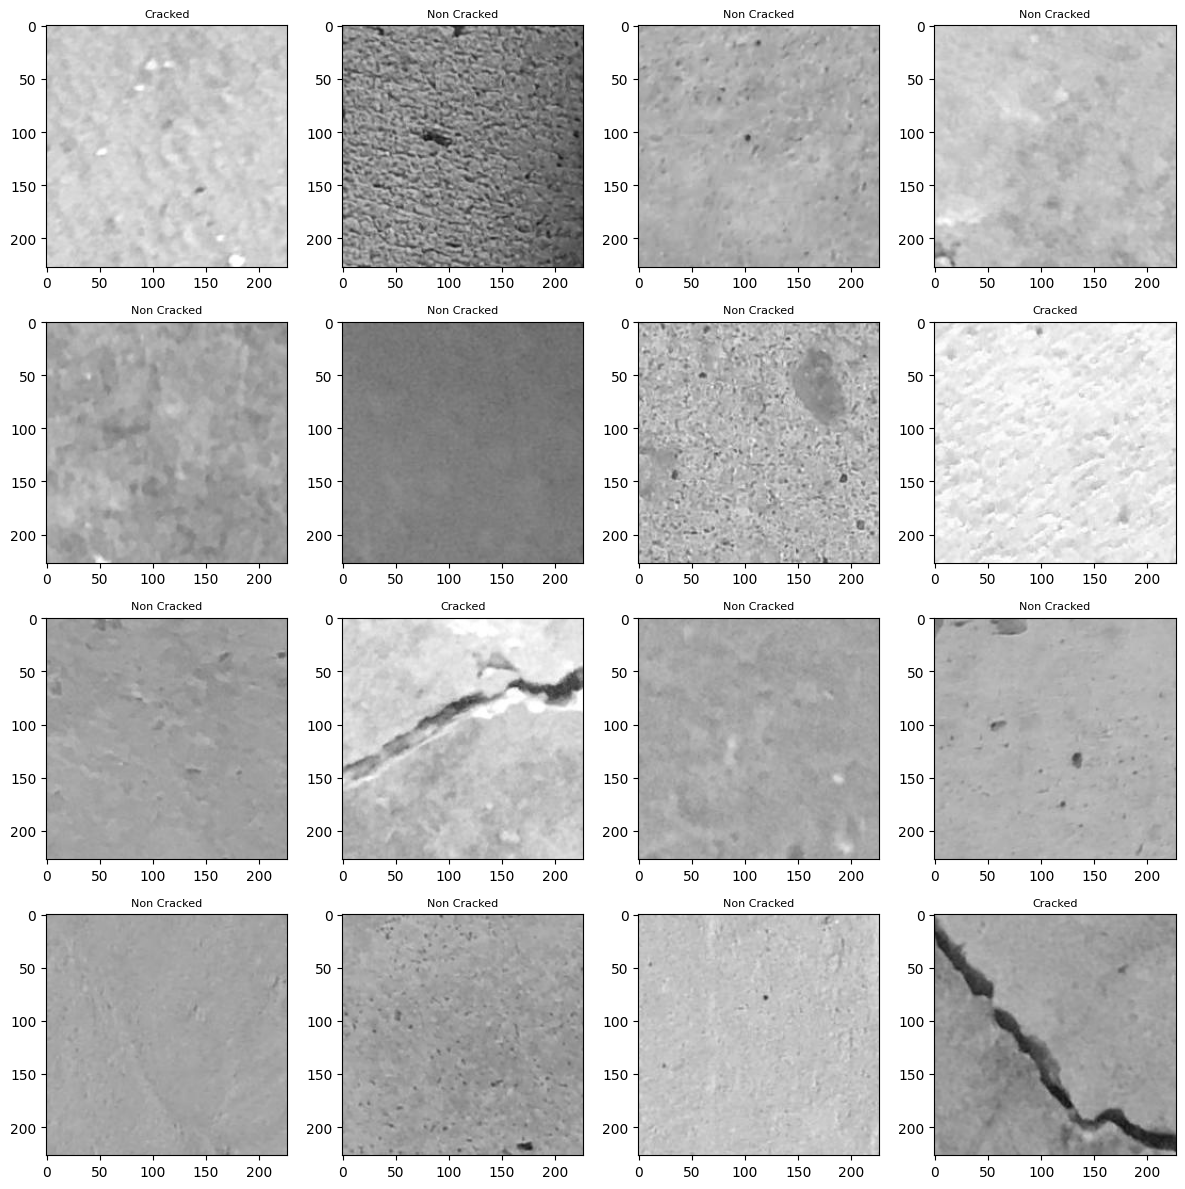

In [8]:
plt.figure(figsize=(12, 12))

sample_df = df.sample(16, random_state=11)

for i in range(16):
    img_path = sample_df.iloc[i]['resized_path']
    label = sample_df.iloc[i]['class']

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=8)

plt.tight_layout()
plt.show()